In [5]:
## vertical eddy
from smode_import import *

In [3]:
da = xr.open_dataset('MVP.nc')
mask = np.isnan(da.temp) | np.isnan(da.salt) | np.isnan(da.chla)
# Apply this mask to all variables in the dataset
da['rho'] = da['rho'].where(~mask)
da

<xarray.Dataset> Size: 11MB
Dimensions:   (pressure: 101, time: 2322)
Coordinates:
  * pressure  (pressure) float64 808B 0.5 1.5 2.5 3.5 ... 97.5 98.5 99.5 100.5
  * time      (time) datetime64[ns] 19kB 2023-04-16T02:59:26.999997952 ... 20...
Data variables:
    temp      (pressure, time) float64 2MB nan nan nan nan ... 9.525 9.519 nan
    salt      (pressure, time) float64 2MB nan nan nan nan ... 33.94 33.94 nan
    rho       (pressure, time) float64 2MB nan nan nan ... 1.027e+03 nan
    oxy       (pressure, time) float64 2MB ...
    chla      (pressure, time) float64 2MB nan nan nan nan ... 0.2732 0.2407 nan
    turb      (pressure, time) float64 2MB ...
    lat       (time) float64 19kB ...
    lon       (time) float64 19kB ...

5.922945160000001


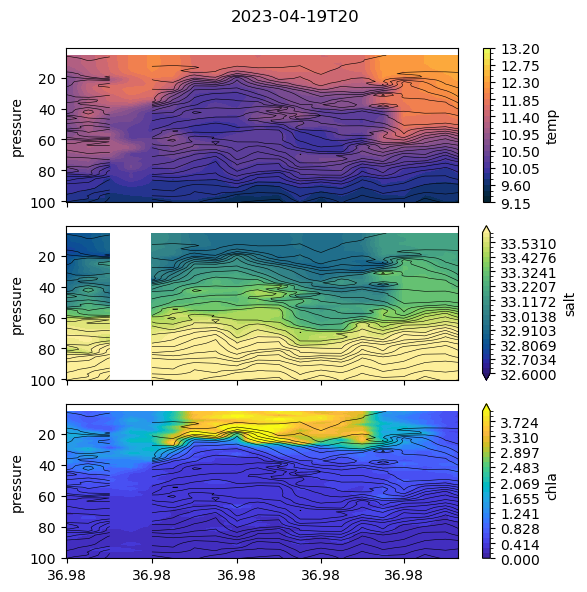

6.889757285714288


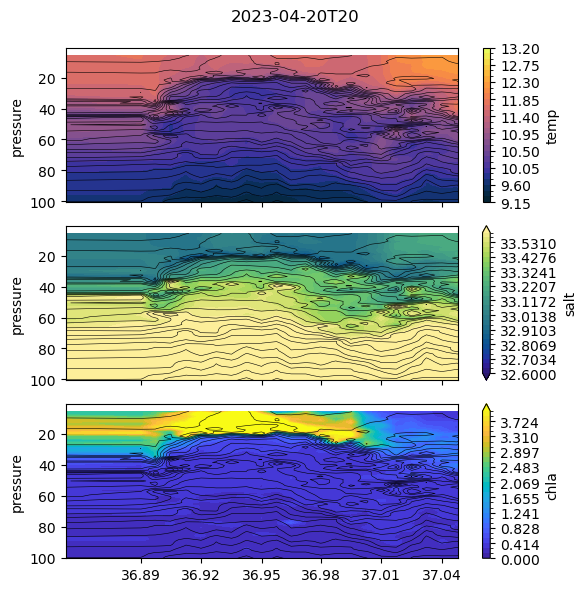

5.761222377777778


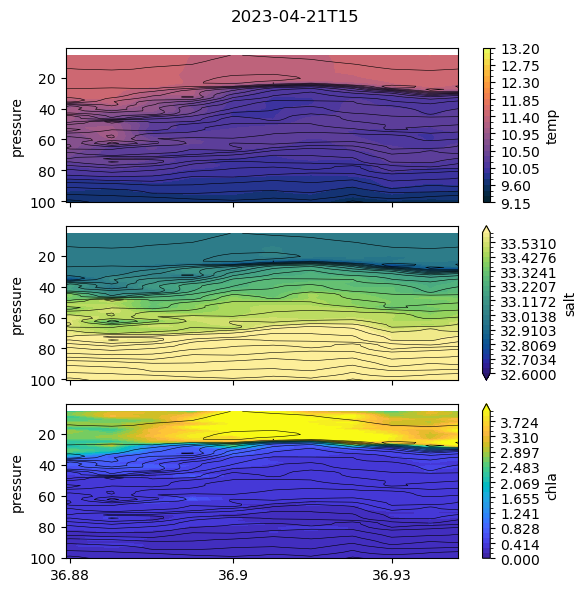

4.918911311111112


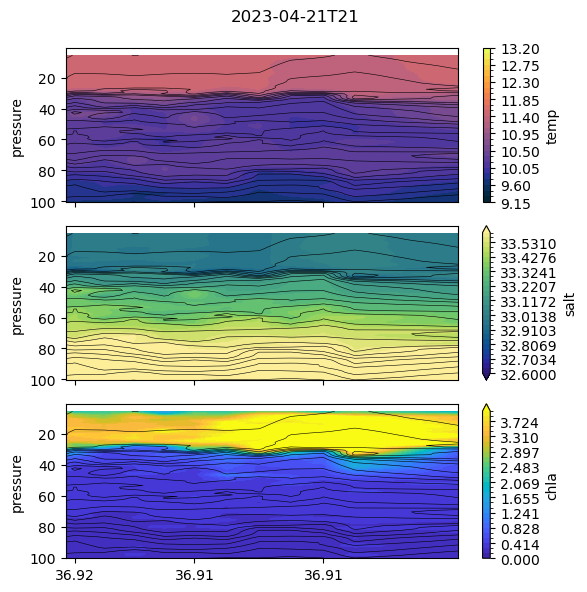

4.820346821052631


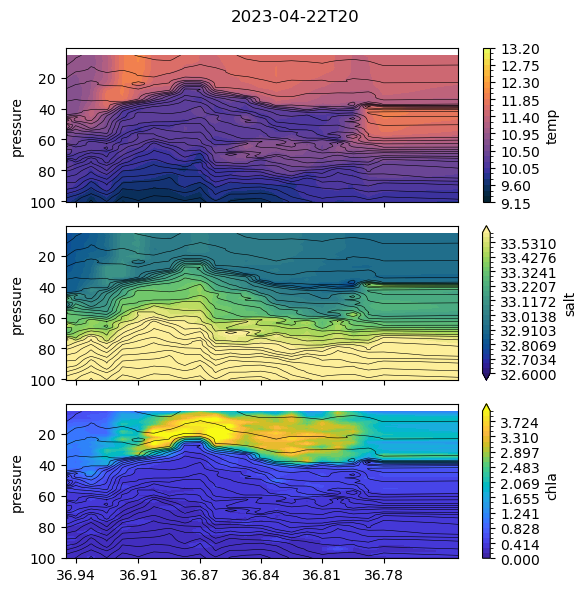

4.131078294444445


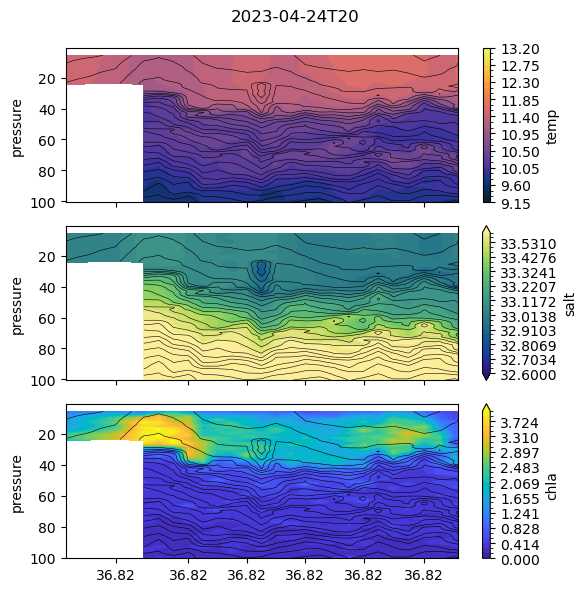

In [156]:
# times we crossed the eddy

times_crossing = ['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]

time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T22:00:00', '2023-04-23T00:00:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
]

for i in range(6):
    
    #time_obj = datetime.strptime(time_str, '%Y-%m-%dT%H')
    #time_minus = time_obj - timedelta(hours=dt)
    #time_plus = time_obj + timedelta(hours=dt)
    #time_minus_str = time_minus.strftime('%Y-%m-%dT%H')
    #time_plus_str = time_plus.strftime('%Y-%m-%dT%H')
    
    fig, ax = plt.subplots(3,1,figsize=(6,3*2),sharex=True)
    #da_ = da.sel(time=slice(time_minus_str,time_plus_str))#.resample(time='0.2h').mean()
    da_ = da.sel(time=slice(time_crossing_intervals[i][0],
                            time_crossing_intervals[i][1]))
    print(da_.chla.max().values)

    
    da.temp.plot.contourf(levels=30,ax=ax[0],cmap=cm.thermal,x='time')
    da.salt.plot.contourf(levels=30,ax=ax[1],cmap=cm.haline,x='time',vmin=32.6,vmax=33.6)
    da.chla.plot.contourf(levels=30,ax=ax[2],cmap=parula,x='time',vmin=0,vmax=4)
    
    #plt.suptitle(times_crossing)
    
    # set xlim to larger than eddy
    dt=0. #hour
    for axis in ax:
        #ax[-1].set_xticks(np.linspace(pd.Timestamp(time_minus_str),pd.Timestamp(time_plus_str),5), 
        #            np.round(np.linspace(da_.time.min(),da_.time.max(),5),1), rotation=20)
        axis.set_xlim(pd.Timestamp(time_crossing_intervals[i][0])- timedelta(hours=dt),
                    pd.Timestamp(time_crossing_intervals[i][1])+ timedelta(hours=dt))
        
        da.rho.plot.contour(levels=40,x='time',colors='k',linewidths=0.4,ax=axis)
        axis.set_xlabel('')
        axis.invert_yaxis()
        
    plt.suptitle(times_crossing[i])
    ax[-1].set_xticks(da_.time[::4],np.round(da_.lat[::4].values,2))
    
    plt.tight_layout()
    plt.show();
    

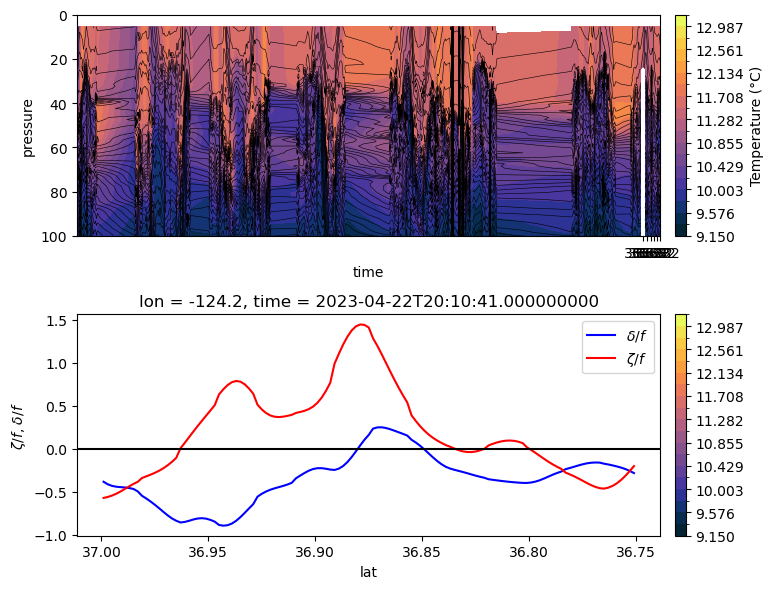

In [158]:
dt = 0.1
i = 4
fig, ax = plt.subplots(2, 1, figsize=(8, 6), gridspec_kw={'height_ratios': [1, 1]})

# Plot the contour and contourf for density and temperature
rho_plot = da.rho.plot.contour(levels=50, x='time', colors='k', linewidths=0.4, ax=ax[0])
temp_plot = da.temp.plot.contourf(levels=np.linspace(9.15, 13.2, 20), x='time', cmap=cm.thermal, ax=ax[0], add_colorbar=False)

# Add colorbar to the first plot
cbar = fig.colorbar(temp_plot, ax=ax[0], orientation='vertical', pad=0.02)
cbar.set_label('Temperature (°C)')

# Set time limits and y-axis limits
ax[0].set_xlim(pd.Timestamp(time_crossing_intervals[i][0]) - timedelta(hours=dt),
               pd.Timestamp(time_crossing_intervals[i][1]) + timedelta(hours=dt))
ax[0].set_ylim(0, 100)
ax[0].invert_yaxis()
ax[0].set_xticks(da_.time[::4],np.round(da_.lat[::4].values,2))

# Open the dataset and select the appropriate time slice
ds = xr.open_dataset('dopplerscatt_gridded.nc')
t1 = times_crossing[i]
t2 = (datetime.strptime(t1, '%Y-%m-%dT%H') + timedelta(hours=10)).strftime('%Y-%m-%dT%H')

ds_ = ds.sel(time=slice(t1, t2)).isel(time=0)
f = coriolis_parameter(37)

# Plot the vorticity and divergence over f in the second subplot
(ds_.sel(lat=slice(36.75, 37)).sel(lon=-124.17, method='nearest').divergence / f).plot(label=r'$\delta/f$', color='b', ax=ax[1])
(ds_.sel(lat=slice(36.75, 37)).sel(lon=-124.17, method='nearest').vorticity / f).plot(label=r'$\zeta/f$', color='r', ax=ax[1])
cbar = fig.colorbar(temp_plot, ax=ax[1], orientation='vertical', pad=0.02)

ax[1].axhline(0, color='k')
ax[1].legend()
ax[1].set_ylabel(r'$\zeta/f$, $\delta/f$')
ax[1].invert_xaxis()
# Adjust the layout
plt.tight_layout()
plt.show();

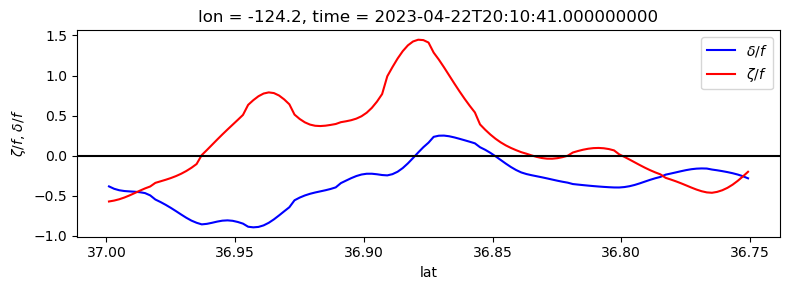

In [168]:
# Open the dataset and select the appropriate time slice
ds = xr.open_dataset('dopplerscatt_gridded.nc')
t1 = times_crossing[i]
t2 = (datetime.strptime(t1, '%Y-%m-%dT%H') + timedelta(hours=10)).strftime('%Y-%m-%dT%H')

ds_ = ds.sel(time=slice(t1, t2)).isel(time=0)
f = coriolis_parameter(37)
plt.figure(figsize=(8,3))
# Plot the vorticity and divergence over f in the second subplot
(ds_.sel(lat=slice(36.75, 37)).sel(lon=-124.17, method='nearest').divergence / f).plot(label=r'$\delta/f$', color='b')
(ds_.sel(lat=slice(36.75, 37)).sel(lon=-124.17, method='nearest').vorticity / f).plot(label=r'$\zeta/f$', color='r')
cbar = fig.colorbar(temp_plot, ax=ax[1], orientation='vertical', pad=0.02)

plt.axhline(0, color='k')
plt.legend()
plt.ylabel(r'$\zeta/f$, $\delta/f$')
plt.gca().invert_xaxis()
# Adjust the layout
plt.tight_layout()
plt.show();

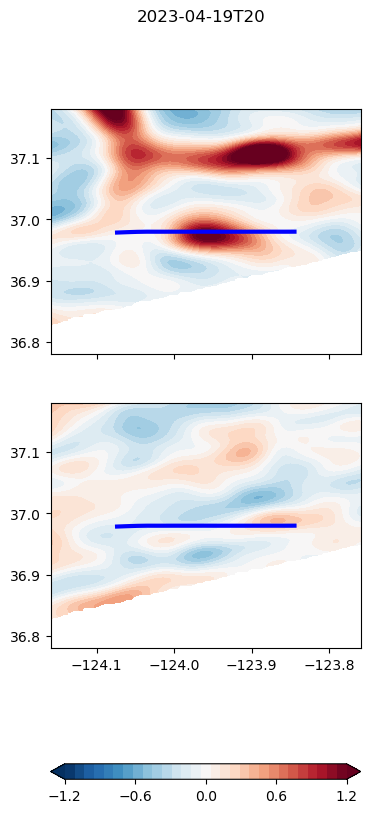

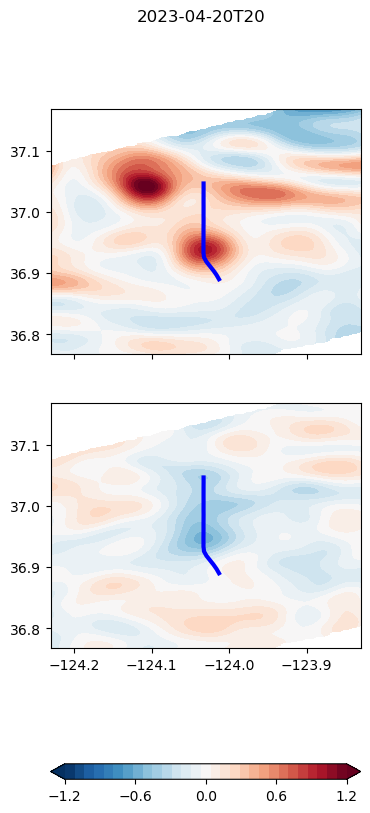

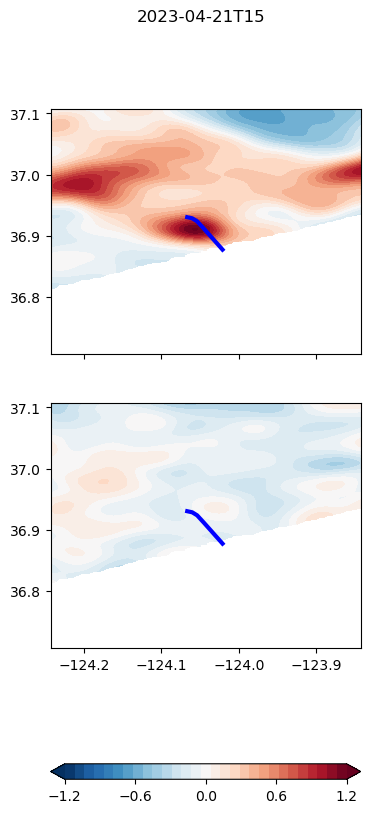

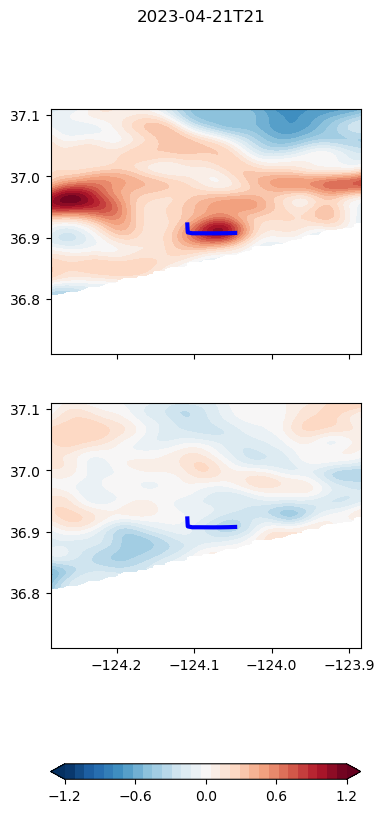

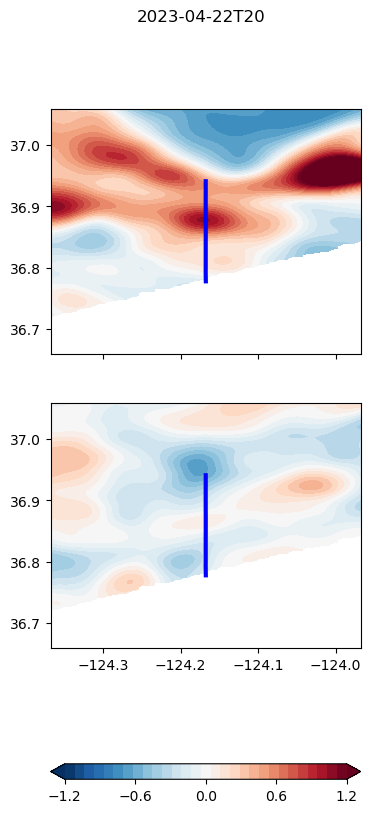

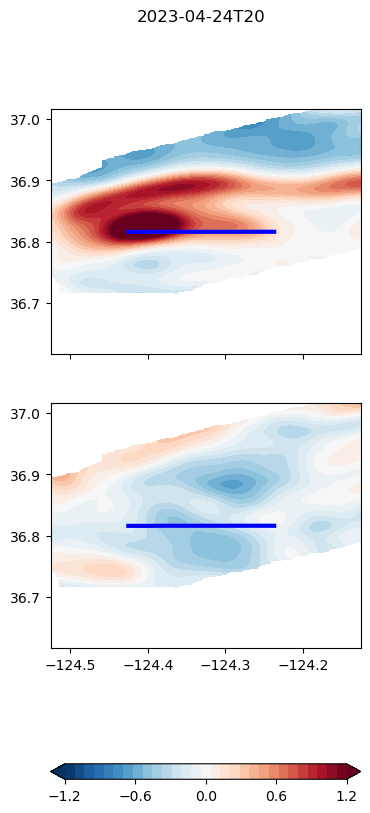

In [130]:
# Plot dopplerscatt vorticity/divergence and ship trajectories
# during eddy crossing

ds = xr.open_dataset('dopplerscatt_gridded.nc')

def plot_pass(da,time_slice,ax,c='b',lw=3):
    da_   = da.sel(time=slice(time_slice[0],time_slice[1]))
    #ax.plot(da.lon,da.lat,'k',linewidth=0.8) # all lines
    ax.plot(da_.lon, da_.lat, color=c, linewidth=lw) # at time of eddy crossing
    #ax.plot(da_.lon[0], da_.lat[0], 'or') # start
    mean_lon, mean_lat = da_.lon.mean(), da_.lat.mean()
    ax.set_xlim(mean_lon-0.2,mean_lon+0.2); plt.ylim(mean_lat-0.2,mean_lat+0.2)

for i in range(6):
    time_slice = time_crossing_intervals[i]
    
    fig, ax = plt.subplots(2,1,figsize=(4,10),sharey=True,sharex=True)
    
    #ds_ = ds.sel(time=slice('2023-04-22','2023-04-23')).isel(time=0)
    t1 = times_crossing[i]
    t2 = datetime.strptime(t1, '%Y-%m-%dT%H') + timedelta(hours=10)
    t2 = t2.strftime('%Y-%m-%dT%H')
    
    ds_ = ds.sel(time=slice(t1,t2)).isel(time=0)
    lons,lats=np.meshgrid(ds_.lon,ds_.lat)
    f=coriolis_parameter(37)
    
    vor_smoothed = scipy.ndimage.gaussian_filter(ds_.vorticity,5)
    div_smoothed = scipy.ndimage.gaussian_filter(ds_.divergence,5)

    levels=np.linspace(-1.2,1.2,30)
    p=ax[0].contourf(lons,lats,vor_smoothed/f,levels,
                   cmap='RdBu_r',extend='both')
    ax[1].contourf(lons,lats,div_smoothed/f,levels,
                   cmap='RdBu_r',extend='both')
    cbar=plt.colorbar(p, ax=ax.ravel().tolist(),orientation='horizontal')
    cbar.set_ticks(np.linspace(-1.2,1.2,5))
    for axis in ax: plot_pass(da,time_slice,axis,'b')
    
    plt.suptitle(str(ds_.time.values)[0:13])
    plt.show();

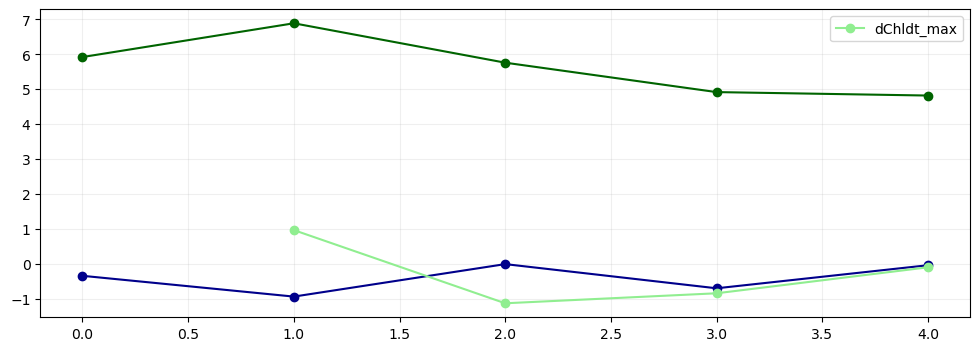

In [114]:
# Divergence and Chlorohyll at the center

eddy_mid_div = [-0.34199998, -0.93720104, -0.00695569, -0.69926071, -0.03903597]
eddy_mid_chl = [5.922945160000001,6.889757285714288,5.761222377777778,4.918911311111112,4.820346821052631]

plt.figure(figsize=(12,4))
plt.plot(eddy_mid_div,'o-',color='darkblue')
plt.plot(eddy_mid_chl,'o-',color='darkgreen')
plt.plot(np.arange(1,5),np.diff(eddy_mid_chl),'o-',color='lightgreen',label='dChldt_max')
plt.grid(alpha=0.2)
plt.legend()

In [ ]:
#ds_ = ds.sel(time=slice('2023-04-22','2023-04-23')).isel(time=0)
t1 = times_crossing[i]
t2 = datetime.strptime(t1, '%Y-%m-%dT%H') + timedelta(hours=10)
t2 = t2.strftime('%Y-%m-%dT%H')

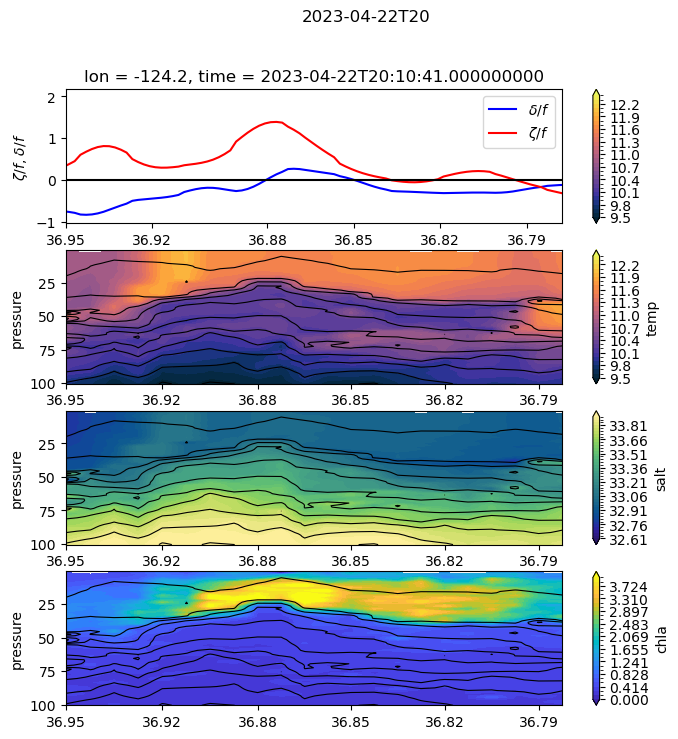

In [7]:
# Transect eddy-crossing

da = xr.open_dataset('MVP.nc')
da

# time we crossed the eddy
times_dopplerscatt=['2023-04-19T20','2023-04-20T20',
                  '2023-04-21T15','2023-04-21T21',
                  '2023-04-22T20','2023-04-24T20',]
time_crossing_intervals = [
    ['2023-04-20T03:20:00', '2023-04-20T05:00:00'],
    ['2023-04-20T21:00:00', '2023-04-20T23:00:00'],
    ['2023-04-21T16:40:00', '2023-04-21T17:25:00'],
    ['2023-04-21T18:30:00', '2023-04-21T19:26:00'],
    ['2023-04-22T21:55:00', '2023-04-22T23:40:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00'],
    ['2023-04-24T21:40:00', '2023-04-24T23:30:00']
]
da['rho'] = da.rho.where(da.salt >= 32.5)

orientations = ['horizontal','vertical','vertical','horizontal','vertical']
reverse=[False,False,False,False,True]
i=4

fig, ax = plt.subplots(4,1,figsize=(8,4*2))
da_ = da.sel(time=slice(time_crossing_intervals[i][0],
                        time_crossing_intervals[i][1]))

# Vorticity + divergence on first panel
ds = xr.open_dataset('dopplerscatt_gridded.nc')
t1 = times_dopplerscatt[i]
t2 = (datetime.strptime(t1, '%Y-%m-%dT%H') + timedelta(hours=10)).strftime('%Y-%m-%dT%H')

ds_ = ds.sel(time=slice(t1, t2)).isel(time=0)
f = coriolis_parameter(37)

axis=ax[0]
# Plot the vorticity and divergence over f in the second subplot
lon0,lon1=da_.lon.min().values,da_.lon.max().values
lat0,lat1=da_.lat.min().values,da_.lat.max().values
if orientations[i]=='vertical':
    (ds_.sel(lon=lon0, method='nearest').divergence / f).plot(label=r'$\delta/f$', color='b', ax=axis)
    (ds_.sel(lon=lon0, method='nearest').vorticity / f).plot(label=r'$\zeta/f$', color='r', ax=axis)
    axis.set_xlim(lat0,lat1)
    axis.set_xticks(np.round(da_.lat[::4].values,2))
elif orientations[i]=='horizontal':
    (ds_.sel(lat=lat0, method='nearest').divergence / f).plot(label=r'$\delta/f$', color='b', ax=axis)
    (ds_.sel(lat=lat0, method='nearest').vorticity / f).plot(label=r'$\zeta/f$', color='r', ax=axis)
    axis.set_xlim(lon0,lon1)
    axis.set_xticks(np.round(da_.lon[::4].values,2))
#cbar = fig.colorbar(temp_plot, ax=axis, orientation='vertical', pad=0.02)
if reverse[i]==1: axis.invert_xaxis()

axis.axhline(0, color='k')
axis.legend()
axis.set_ylabel(r'$\zeta/f$, $\delta/f$')

# Temp + Salt + Chl on other panel
p=da.temp.plot.contourf(levels=30,ax=ax[1],cmap=cm.thermal,x='time',robust=True)
da.salt.plot.contourf(levels=50,ax=ax[2],cmap=cm.haline,x='time',robust=True)#vmin=32.4,vmax=33.8)
da.chla.plot.contourf(levels=30,ax=ax[3],cmap=parula,x='time',vmin=0,vmax=4)

dt=0. #hour
for axis in ax[1::]:
    axis.set_xlim(pd.Timestamp(time_crossing_intervals[i][0])- timedelta(hours=dt),
                pd.Timestamp(time_crossing_intervals[i][1])+ timedelta(hours=dt))
    
    da.rho.plot.contour(levels=20,x='time',colors='k',linewidths=0.8,ax=axis)
    axis.set_xlabel('')
    axis.invert_yaxis()
    axis.set_xticks(da_.time[::4], '')
    
    
plt.colorbar(p,ax=ax[0])
plt.suptitle(times_dopplerscatt[i])

# Set x-limits for subsequent axes
for axis in ax[1::]:
    axis.set_xticks(da_.time[::4])  # Set tick positions
    if orientations[i]=='vertical':
        axis.set_xticklabels(np.round(da_.lat[::4].values,2))  # Set the labels
    if orientations[i]=='horizontal':
        axis.set_xticklabels(np.round(da_.lon[::4].values,2))  # Set the labels
    
    axis.set_xlim(da_.time[0], da_.time[-1])
    
#plt.tight_layout()
plt.show();


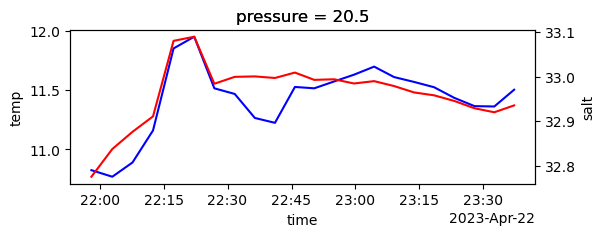

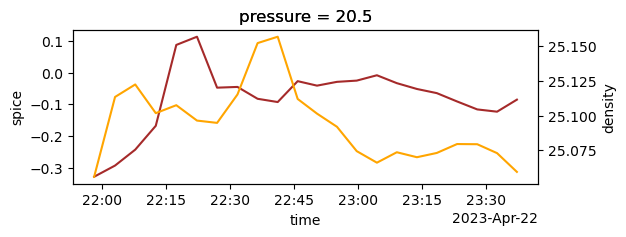

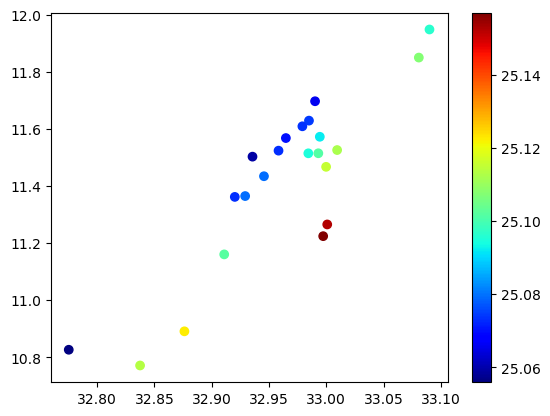

In [10]:
p=20

temp = da_.temp.sel(pressure=p,method='nearest')
salt = da_.salt.sel(pressure=p,method='nearest')
spice = gsw.spiciness0(salt,temp)
dens = gsw.density.rho(salt,temp,p=da_.pressure.sel(pressure=p,method='nearest').values)-1000

plt.figure(figsize=(6,2))
temp.plot(x='time',color='b',label='temp')
ax2=plt.gca().twinx()
salt.plot(x='time',color='r',ax=ax2,label='salt')
plt.show();

plt.figure(figsize=(6,2))
spice.plot(x='time',color='brown',label='spice')
plt.gca().set_ylabel('spice')
ax2=plt.gca().twinx()
dens.plot(x='time',color='orange',ax=ax2,label='density')
ax2.set_ylabel('density')
plt.show();

plt.figure()
plt.scatter(salt,temp,c=dens,cmap='jet')
plt.colorbar();